In [1]:
import rioxarray as rix

In [2]:
example_tiff = r"../example_data/20241005bC0823515w353730n.tif"

In [4]:
helene_example = rix.open_rasterio(example_tiff)

In [34]:
helene_example

<xarray.DataArray (band: 3, y: 9415, x: 9415)> Size: 266MB
array([[[155, 158, ...,  51,  58],
        [145, 153, ...,  50,  50],
        ...,
        [  0,   0, ..., 142, 139],
        [  0,   0, ..., 145, 142]],

       [[154, 157, ...,  66,  73],
        [144, 152, ...,  65,  65],
        ...,
        [  0,   0, ..., 149, 146],
        [  0,   0, ..., 152, 149]],

       [[160, 163, ...,  85,  92],
        [150, 158, ...,  84,  84],
        ...,
        [  0,   0, ..., 141, 138],
        [  0,   0, ..., 144, 141]]], shape=(3, 9415, 9415), dtype=uint8)
Coordinates:
  * band         (band) int64 24B 1 2 3
  * y            (y) float64 75kB 35.63 35.63 35.63 35.63 ... 35.61 35.61 35.61
  * x            (x) float64 75kB -82.59 -82.59 -82.59 ... -82.57 -82.57 -82.57
    spatial_ref  int64 8B 0
Attributes:
    TIFFTAG_DATETIME:        2024:10:05 23:59:59
    TIFFTAG_MINSAMPLEVALUE:  0
    TIFFTAG_MAXSAMPLEVALUE:  255
    AREA_OR_POINT:           Point
    scale_factor:            1.0
    add_offset:              0.0

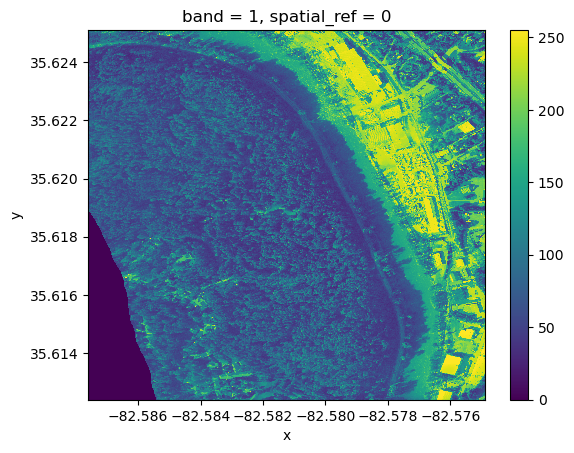

In [9]:
helene_example[0].plot()

In [11]:
import matplotlib.pyplot as plt

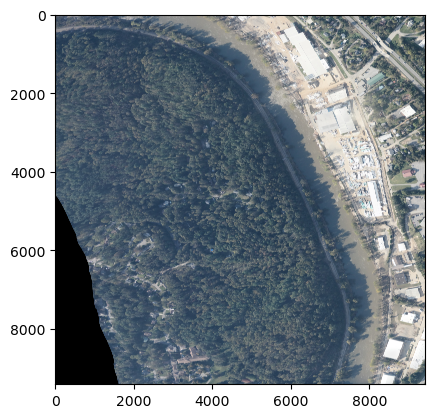

In [17]:
plt.imshow(helene_example.transpose('y', 'x', 'band').values)

In [10]:
from skimage.color import rgb2gray

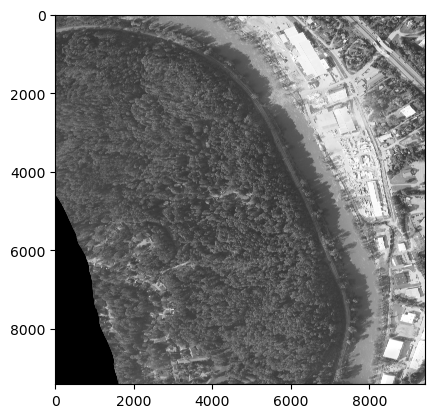

In [19]:
plt.imshow(rgb2gray(helene_example.transpose('y', 'x', 'band')), cmap=plt.cm.gray)

In [20]:
pre_storm_fn = r"C:\Users\sfreeman\Downloads\USDA_Pre_Storm-20260317T143521Z-1-001\USDA_Pre_Storm\m_3508228_nw_17_060_20220923.tif"

In [21]:
helene_prestorm = rix.open_rasterio(pre_storm_fn)

In [22]:
helene_prestorm

<xarray.DataArray (band: 4, y: 12380, x: 10300)> Size: 510MB
[510056000 values with dtype=uint8]
Coordinates:
  * band         (band) int64 32B 1 2 3 4
  * y            (y) float64 99kB 3.944e+06 3.944e+06 ... 3.936e+06 3.936e+06
  * x            (x) float64 82kB 3.525e+05 3.525e+05 ... 3.587e+05 3.587e+05
    spatial_ref  int64 8B 0
Attributes:
    TIFFTAG_XRESOLUTION:     1
    TIFFTAG_YRESOLUTION:     1
    TIFFTAG_RESOLUTIONUNIT:  1 (unitless)
    AREA_OR_POINT:           Area
    scale_factor:            1.0
    add_offset:              0.0

In [25]:
rgb_prestorm = helene_prestorm.sel(band=slice(1,3))

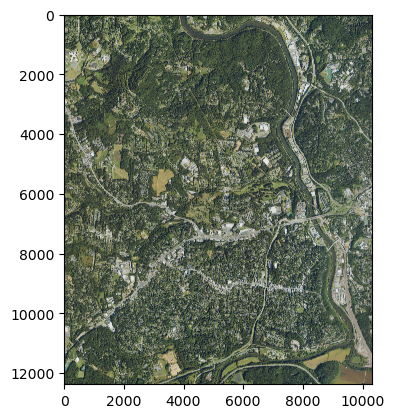

In [26]:
plt.imshow(rgb_prestorm.transpose('y', 'x', 'band'))

In [29]:
helene_example.rio.bounds()

(-82.5876, 35.6124, -82.57489999999999, 35.6251)

In [35]:
helene_example.rio.crs

CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]')

In [37]:
prestorm_reproj = rgb_prestorm.rio.reproject(helene_example.rio.crs)

In [39]:
reproj_same_box = prestorm_reproj.rio.clip_box(*helene_example.rio.bounds())

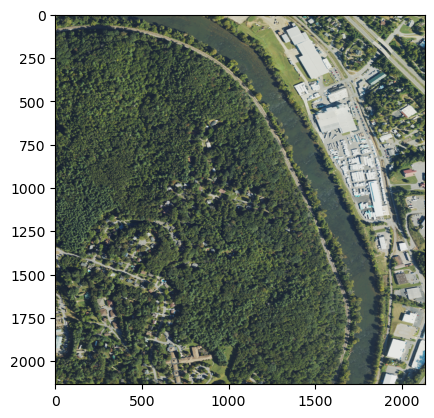

In [ ]:
plt.imshow(reproj_same_box.transpose('y', 'x', 'band'))

In [42]:
from skimage.exposure import match_histograms


In [45]:
matched_post_storm = match_histograms(helene_example.values, reproj_same_box.values, channel_axis=0)


In [47]:
helene_example_matched = helene_example.copy()

In [48]:
helene_example_matched.values = matched_post_storm

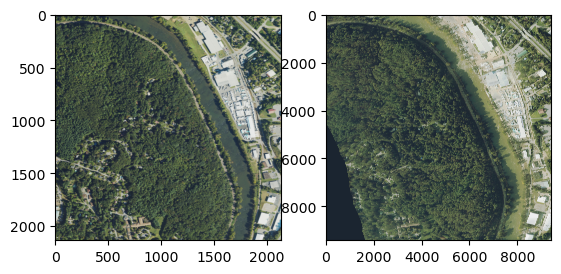

In [51]:
fig, axarr = plt.subplots(1,2)
axarr[0].imshow(reproj_same_box.transpose('y', 'x', 'band'))
axarr[1].imshow(helene_example_matched.transpose('y', 'x', 'band'))

In [ ]:
axarr[1].imshow(helene_example_matched.transpose('y', 'x', 'band'))

In [56]:
helene_example_matched.band[0]

<xarray.DataArray 'band' ()> Size: 8B
array(1)
Coordinates:
    band         int64 8B 1
    spatial_ref  int64 8B 0

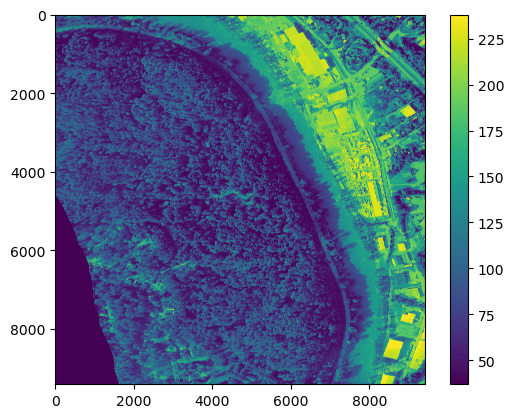

In [58]:
plt.imshow(helene_example_matched[1])
plt.colorbar()

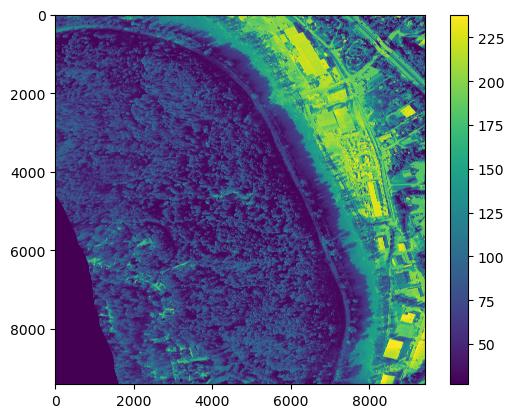

In [59]:
plt.imshow(helene_example_matched[0])
plt.colorbar()